In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.weightstats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
caminho = 'C:\Iniciacao_Cientifica\Dados_CNH/Medicao01_PTO.txt'
colunas =  ["tempo[s]", "aceleracao_x[g]", "aceleracao_y[g]", "aceleracao_z[g]"]

In [28]:
df_CNH = pd.read_csv(caminho, sep=r'\s+', header=None, names=colunas, index_col = 0)

In [29]:
df_CNH.head(10)

,aceleracao_x[g],aceleracao_y[g],aceleracao_z[g]
tempo[s],,,
0.000,-0.01278,-0.008438,0.003294
0.001,-0.00848,-0.002438,0.019594
0.002,-0.00998,-0.000438,0.028194
0.003,-0.01178,0.006562,0.014694
0.004,-0.00528,0.003562,0.022794
0.005,-0.00458,-0.008438,0.021894
0.006,-0.00988,-0.005438,0.022094
0.007,-0.01098,0.000562,0.028394
0.008,-0.00468,0.000562,0.021894


In [30]:
df_CNH.isnull().any()

aceleracao_x[g]    False
aceleracao_y[g]    False
aceleracao_z[g]    False
dtype: bool

In [43]:
df_CNH.describe()

,aceleracao_x[g],aceleracao_y[g],aceleracao_z[g]
count,9.500400e+05,9.500400e+05,9.500400e+05
mean,7.325163e-10,-9.644299e-10,1.038487e-10
std,4.559825e-01,4.801431e-01,1.916370e-01
min,-1.766080e+00,-2.590438e+00,-1.268606e+00
25%,-2.434204e-01,-3.184384e-01,-1.077062e-01
50%,-1.380401e-03,-5.438399e-03,1.009379e-02
75%,2.585196e-01,2.295616e-01,1.126938e-01
max,1.804920e+00,2.655562e+00,2.324394e+00


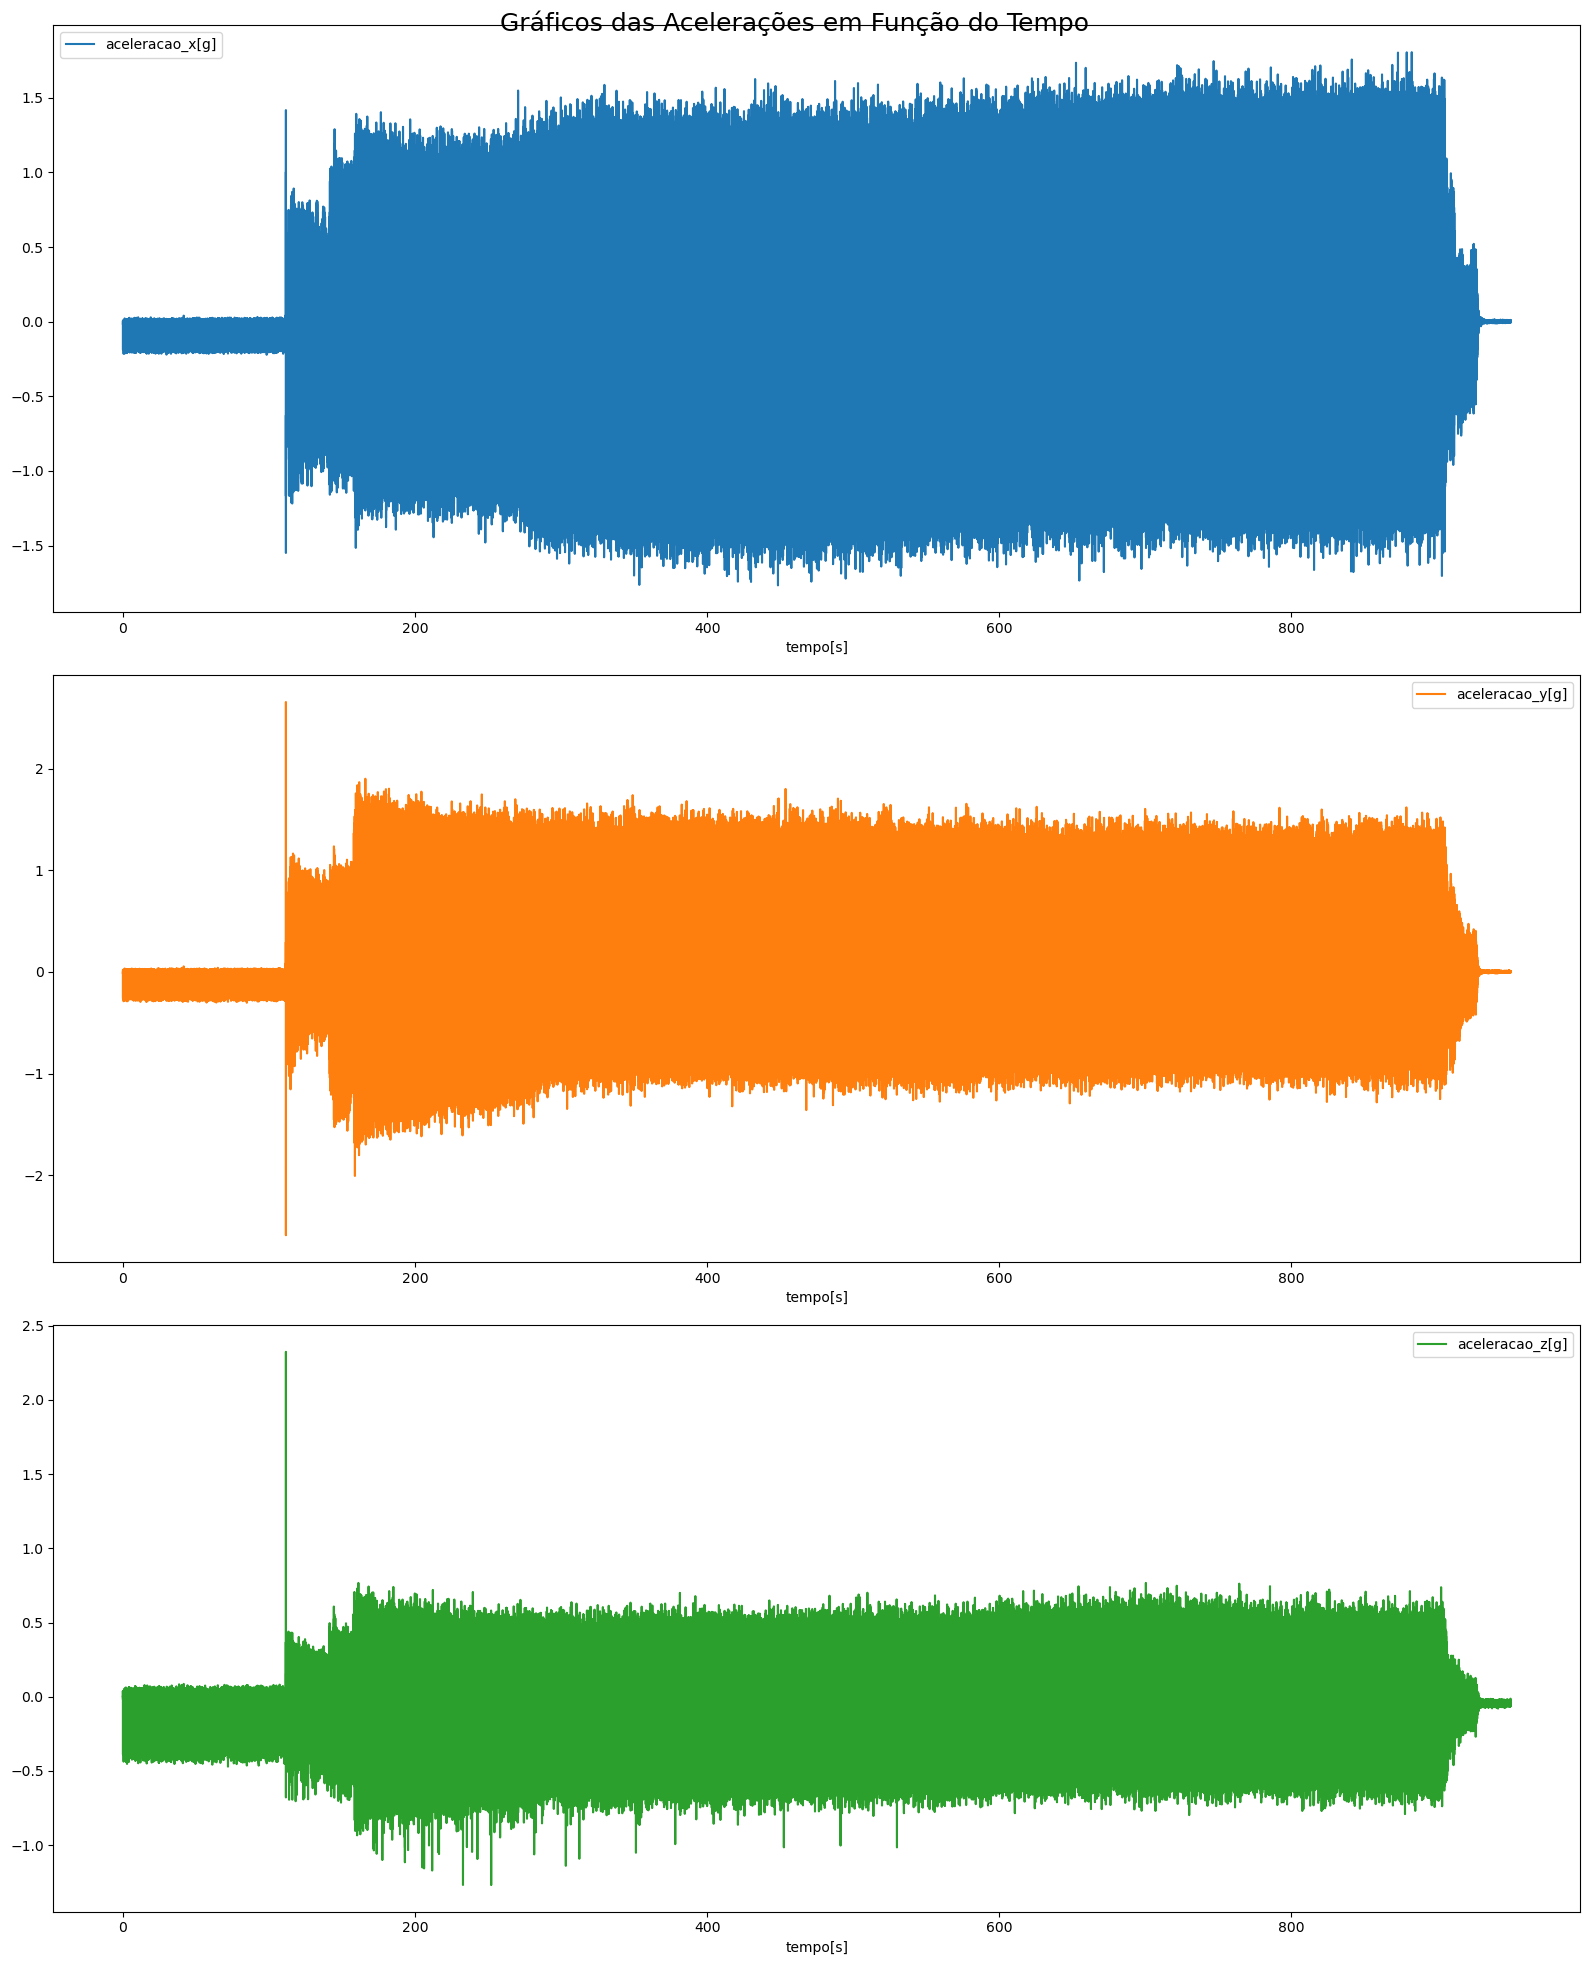

In [31]:
#Gráficos
# Aqui está a parte que altera o layout para 4 linhas e 2 colunas
axes = df_CNH.plot(subplots=True, figsize=(16, 20), sharex=False)

# Adiciona o super título no topo
plt.suptitle('Gráficos das Acelerações em Função do Tempo', fontsize=18, y=0.98)

# Ajusta o espaçamento entre os gráficos para não sobrepor os eixos
plt.tight_layout()

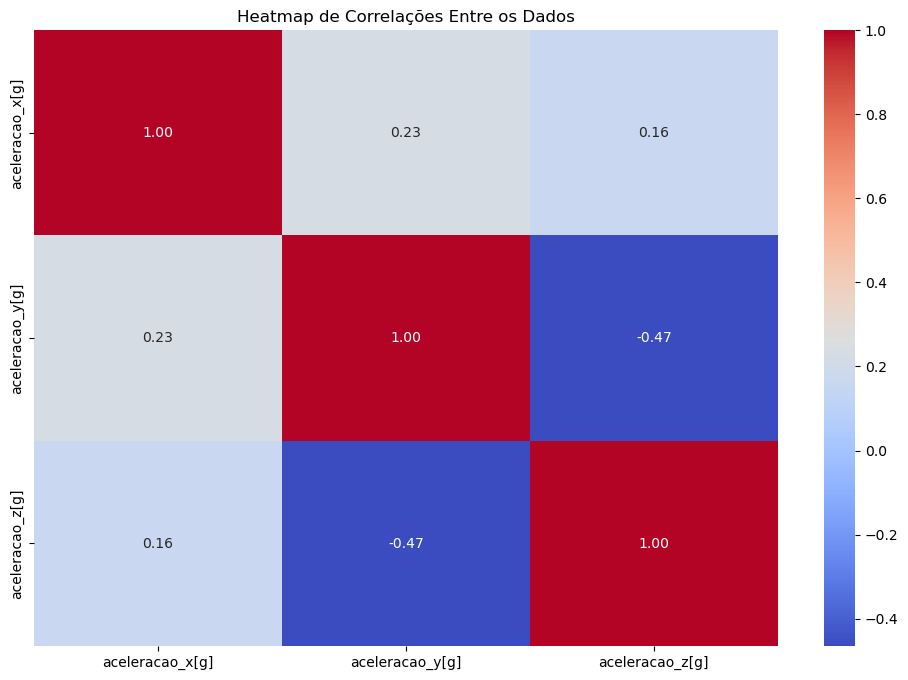

In [45]:
correlacoes_tempo = df_CNH.corr()

plt.figure(figsize = (12, 8))
sns.heatmap(correlacoes_tempo, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Heatmap de Correlações Entre os Dados')
plt.show()

In [33]:
fs = 1000
N = len(df_CNH)
colunas_att =  ["aceleracao_x[g]", "aceleracao_y[g]", "aceleracao_z[g]"]

In [37]:
frequencias = np.fft.rfftfreq(N, d=1 / fs)
fft_valores = np.fft.rfft(df_CNH[colunas_att], axis=0)
magnitudes = np.abs(fft_valores) * (2 / N)

In [39]:
df_CNH_fft = pd.DataFrame(magnitudes, columns=colunas_att, index=frequencias)
df_CNH_fft.index.name = "frequencia[hz]"

In [40]:
df_CNH_fft.head(10)

,aceleracao_x[g],aceleracao_y[g],aceleracao_z[g]
frequencia[hz],,,
0.000000,1.465033e-09,1.928860e-09,2.076974e-10
0.001053,3.654814e-03,5.020666e-03,2.139923e-02
0.002105,1.813007e-03,1.934640e-03,8.244193e-03
0.003158,1.240095e-03,1.181366e-03,4.700418e-03
0.004210,8.200171e-04,9.748105e-04,3.265858e-03
0.005263,7.333093e-04,7.055167e-04,2.526663e-03
0.006316,6.253987e-04,6.302451e-04,2.967337e-03
0.007368,3.905278e-04,3.885605e-04,2.940300e-03
0.008421,3.835119e-04,3.786213e-04,2.645617e-03


In [47]:
df_CNH_fft.describe()

,aceleracao_x[g],aceleracao_y[g],aceleracao_z[g]
count,4.750210e+05,4.750210e+05,4.750210e+05
mean,1.775190e-04,1.711474e-04,1.106465e-04
std,9.186413e-04,9.702322e-04,3.773343e-04
min,1.353002e-09,1.928860e-09,2.076974e-10
25%,5.479575e-05,4.530363e-05,4.134259e-05
50%,1.109712e-04,9.572801e-05,7.948535e-05
75%,1.882864e-04,1.760849e-04,1.289145e-04
max,2.588687e-01,2.295773e-01,6.644177e-02


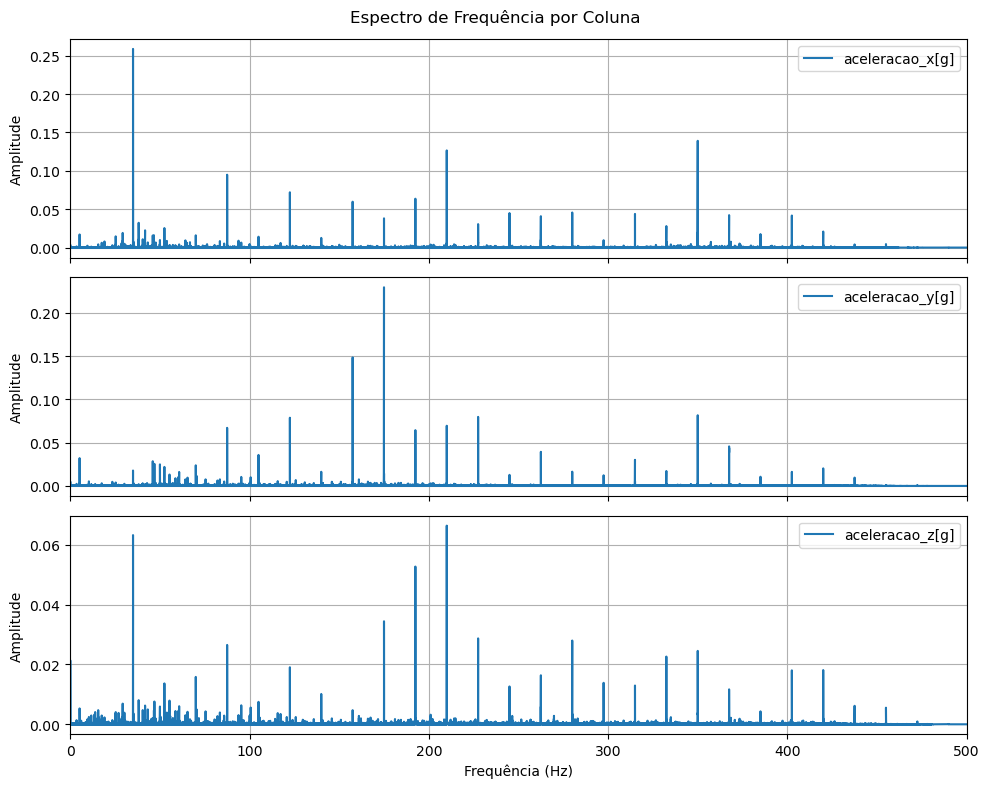

In [42]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for ax, col in zip(axes, colunas_att):
    ax.plot(df_CNH_fft.index, df_CNH_fft[col], label=col)
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")
    ax.grid(True)

axes[-1].set_xlabel("Frequência (Hz)")
plt.suptitle("Espectro de Frequência por Coluna")
plt.xlim(0, fs / 2)  # Limite até a Frequência de Nyquist
plt.tight_layout()
plt.show()

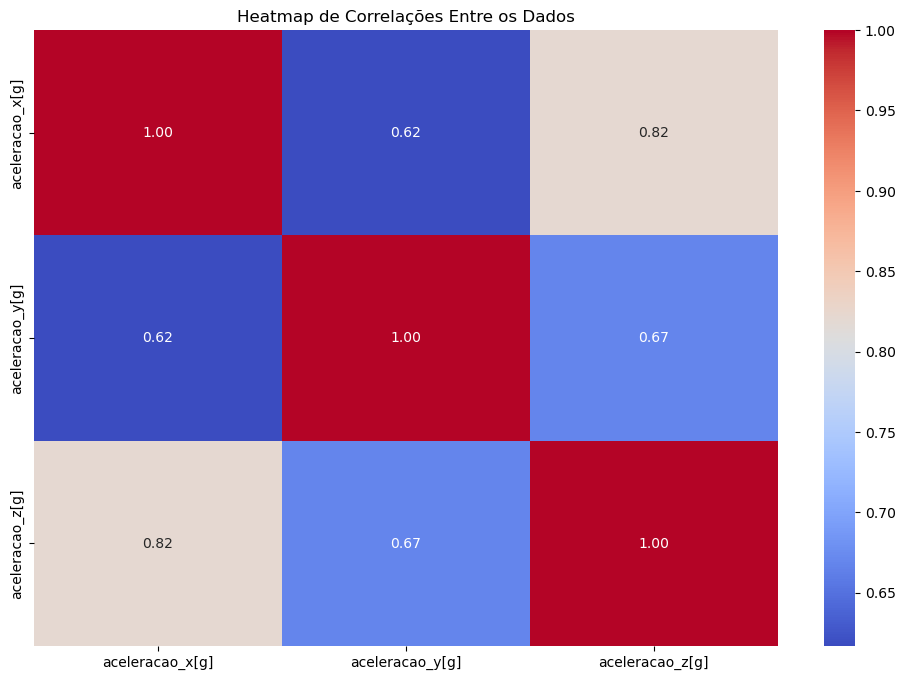

In [46]:
correlacoes_freq = df_CNH_fft.corr()

plt.figure(figsize = (12, 8))
sns.heatmap(correlacoes_freq, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Heatmap de Correlações Entre os Dados')
plt.show()